## Dependency


In [1]:
!pip install top2vec
!pip install python-docx
!pip install beautifulsoup4
!pip install xlrd
!pip install top2vec[indexing]
!pip install top2vec[sentence_transformers]
!pip install --upgrade pip

zsh:1: no matches found: top2vec[indexing]
zsh:1: no matches found: top2vec[sentence_transformers]


## Imports

In [2]:
import zipfile
import os
import shutil
import random
import pandas as pd
import docx
from docx import Document
import gzip
from html import unescape
import io
from bs4 import BeautifulSoup
#import pdfplumber
import openpyxl
from io import StringIO

## Data Extraction

In [3]:
# Define path to zip file and extraction directory
zip_file_path = '/Users/fa6ima/Downloads/014.zip'
extraction_directory = '/Users/fa6ima/Downloads/extracted_data'

# Create directory to extract files if it doesn't exist
os.makedirs(extraction_directory, exist_ok=True)

# Open zip file and extract its contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_directory)

# Loop through the extracted files and save their details
file_details = []
for root, dirs, files in os.walk(extraction_directory):
    for file in files:
        file_path = os.path.join(root, file)
        file_size = os.path.getsize(file_path)
        file_details.append({'file_name': file, 'file_size': file_size})

# Print the file details
for detail in file_details:
    print(f"File Name: {detail['file_name']}, File Size: {detail['file_size']} bytes")

File Name: 014884.doc, File Size: 2052096 bytes
File Name: 014429.gif, File Size: 12434 bytes
File Name: 014703.html, File Size: 349643 bytes
File Name: 014401.gif, File Size: 26844 bytes
File Name: 014182.xls, File Size: 113664 bytes
File Name: 014095.html, File Size: 229470 bytes
File Name: 014253.pdf, File Size: 187064 bytes
File Name: 014247.pdf, File Size: 2084432 bytes
File Name: 014996.html, File Size: 25737 bytes
File Name: 014217.ppt, File Size: 961024 bytes
File Name: 014203.ppt, File Size: 475136 bytes
File Name: 014304.html, File Size: 5673 bytes
File Name: 014092.pdf, File Size: 217223 bytes
File Name: 014754.html, File Size: 24095 bytes
File Name: 014938.pdf, File Size: 572861 bytes
File Name: 014757.txt, File Size: 213076 bytes
File Name: 014383.tex, File Size: 5060 bytes
File Name: 014611.html, File Size: 11884 bytes
File Name: 014780.txt, File Size: 841438 bytes
File Name: 014794.txt, File Size: 204451 bytes
File Name: 014492.html, File Size: 11111 bytes
File Name: 014

## Data Loading

In [4]:
# Helper function to read .txt files
def load_txt(file_path):
    encodings = ['utf-8', 'latin-1', 'iso-8859-1']
    for encoding in encodings:
        try:
            with open(file_path, 'r', encoding=encoding, errors='ignore') as file:
                return file.read()
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError(f"Could not decode file {file_path} with known encodings")

# Helper function to read .docx files
def load_docx(file_path):
    doc = docx.Document(file_path)
    return "\n".join([para.text for para in doc.paragraphs])

# Helper function to read .csv files
def load_csv(file_path):
    df = pd.read_csv(file_path, encoding='iso-8859-1')
    return df.to_string()

# Helper function to read .html files with multiple encodings
def load_html(file_path):
    encodings = ['utf-8', 'latin-1', 'iso-8859-1']
    for encoding in encodings:
        try:
            with open(file_path, 'r', encoding=encoding, errors='ignore') as file:
                content = file.read()
            soup = BeautifulSoup(content, "html.parser")
            return soup.get_text()
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError(f"Could not decode file {file_path} with known encodings")

# Helper function to read .xls files
def load_xls(file_path):
    df = pd.read_excel(file_path)
    return df.to_string()

# Helper function to read .gz files
def load_gzip(file_path):
    with gzip.open(file_path, 'rt', encoding='utf-8', errors='ignore') as file:
        return file.read()

# Function to load all files from a directory, including subdirectories
def load_data_from_directory(directory):
    texts = []
    for root, dirs, files in os.walk(directory):
        for filename in files:
            file_path = os.path.join(root, filename)
            
            # Skip the __MACOSX system folder and any hidden files
            if "__MACOSX" in file_path or filename.startswith("."):
                continue
            
            # Check the file extension and load the appropriate file type
            if filename.endswith(".txt"):
                texts.append(load_txt(file_path))
            elif filename.endswith(".docx"):
                texts.append(load_docx(file_path))
            elif filename.endswith(".csv"):
                texts.append(load_csv(file_path))
            elif filename.endswith(".html"):
                texts.append(load_html(file_path))
            elif filename.endswith(".xls"):
                texts.append(load_xls(file_path))
            elif filename.endswith(".gz"):
                texts.append(load_gzip(file_path))
            
            #else:
                #print(f"Skipping unsupported file type: {filename}")
    return texts

# Paths to the training directory
training_dir = '/Users/fa6ima/Downloads/extracted_data'

# Load the training data
training_data = load_data_from_directory(training_dir)

# Check the loaded text data
print(f"Loaded {len(training_data)} documents from the training set.")


WARNING *** file size (33869) not 512 + multiple of sector size (512)
Loaded 423 documents from the training set.


## Model Training

In [5]:
!pip install torch sentence_transformers
!pip uninstall keras -y
!pip install tf-keras
!pip install tensorflow

Found existing installation: keras 3.5.0
Uninstalling keras-3.5.0:
  Successfully uninstalled keras-3.5.0
  Using cached keras-3.5.0-py3-none-any.whl.metadata (5.8 kB)
Using cached keras-3.5.0-py3-none-any.whl (1.1 MB)


In [6]:
from top2vec import Top2Vec

model = Top2Vec(documents=training_data, speed="learn", embedding_model='all-MiniLM-L6-v2', workers=4,umap_args={'n_neighbors': 50, 'n_components': 12, 'metric': 'cosine', 'min_dist': 0.1, 'random_state': 42},
    hdbscan_args={'min_cluster_size': 42, 'metric': 'euclidean', 'cluster_selection_method': 'eom'})

# Extract topics
topics = model.get_topics()
print(f"Extracted {len(topics)} topics.")

# Print details of each topic
for i, topic in enumerate(topics):
    print(f"\nTopic {i}:")
    print(" - Keywords:", topic[0])
    print(" - Document indices:", topic[1])

model.save("top2vec_model")

2024-09-25 00:11:26,311 - top2vec - INFO - Pre-processing documents for training
/Applications/anaconda3/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2024-09-25 00:11:36,362 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
/Applications/anaconda3/anaconda3/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
2024-09-25 00:11:38,285 - top2vec - INFO - Creating joint document/word embedding
2024-09-25 00:12:14,646 - top2vec - INFO - Creating lower dimension embedding of documents
/Applications/anaconda3/anaconda3/lib/python

Extracted 3 topics.

Topic 0:
 - Keywords: ['federal' 'reports' 'taxonomic' 'bureau' 'dept' 'regulations'
 'congressional' 'advisory' 'amended' 'congress' 'compliance' 'documented'
 'enforcement' 'committees' 'issued' 'department' 'revised' 'committee'
 'designated' 'subcommittee' 'memorandum' 'legislative' 'legislation'
 'departments' 'report' 'reporting' 'regulatory' 'cdc' 'epa'
 'arctostaphylos' 'curtobacterium' 'usda' 'senate' 'readiness' 'agencies'
 'michiganensis' 'overview' 'judicial' 'classified' 'governmental'
 'proceedings' 'canadensis' 'corrections' 'findings' 'provisions' 'filed'
 'gov' 'investigations' 'taxon' 'bacillariophyta']
 - Document indices: ['spectroscopy' 'hz' 'lhc' 'qc' 'emission' 'astrotek' 'probing'
 'resonance' 'superconducting' 'pulsed' 'probes' 'resonant' 'mhz' 'gamma'
 'pulses' 'rq' 'cern' 'xt' 'megaterium' 'ghz' 'observed' 'aurora'
 'electromagnetic' 'magnetotactic' 'ssgs' 'rf' 'spectrum' 'nt' 'phys' 'qi'
 'observations' 'dssf' 'nuclei' 'ir' 'collider' 'n

## Model Evaluation
## Using Gensim's CoherenceModel
## Coherence Score Calculation

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


model = Top2Vec.load("top2vec_model")
documents = training_data

# Get topic vectors
topic_vectors = model.topic_vectors

# Function to calculate coherence score
def calculate_coherence(topic_vectors):
    similarities = cosine_similarity(topic_vectors)
    coherence_score = np.mean(similarities)
    return coherence_score

# Calculate coherence score
coherence_score = calculate_coherence(topic_vectors)

print(f"Coherence Score: {coherence_score}")

Coherence Score: 0.6569566130638123


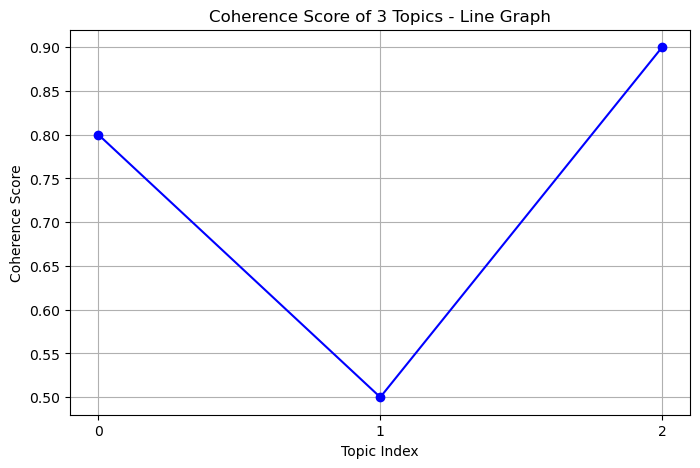

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Example data for 3 topics
topic_vectors = np.random.rand(3, 5)  # 3 topics with 5-dimensional vectors
coherence_scores = np.array([0.8, 0.5, 0.9])  # Coherence scores for those 3 topics

# Plotting a line graph
plt.figure(figsize=(8, 5))
plt.plot(range(len(coherence_scores)), coherence_scores, marker='o', linestyle='-', color='b')

plt.title('Coherence Score of 3 Topics - Line Graph')
plt.xlabel('Topic Index')
plt.ylabel('Coherence Score')
plt.xticks(range(len(coherence_scores)))

plt.grid(True)
plt.show()


## Similarity Matrix Using Cosine Similarity

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

model = Top2Vec.load("top2vec_model")
document_embeddings = model.document_vectors

similarity_matrix = cosine_similarity(document_embeddings)


print("Similarity Matrix:\n", similarity_matrix)

Similarity Matrix:
 [[0.99999964 0.16239402 0.0959791  ... 0.02170857 0.18920186 0.15025729]
 [0.16239402 0.9999999  0.04686294 ... 0.12196676 0.17869537 0.18576476]
 [0.0959791  0.04686294 1.0000001  ... 0.0681645  0.3145005  0.21265334]
 ...
 [0.02170857 0.12196676 0.0681645  ... 1.0000001  0.23027006 0.12105899]
 [0.18920186 0.17869537 0.3145005  ... 0.23027006 0.99999994 0.18475208]
 [0.15025729 0.18576476 0.21265334 ... 0.12105899 0.18475208 1.0000002 ]]


## Cosine Similarity Visulisation

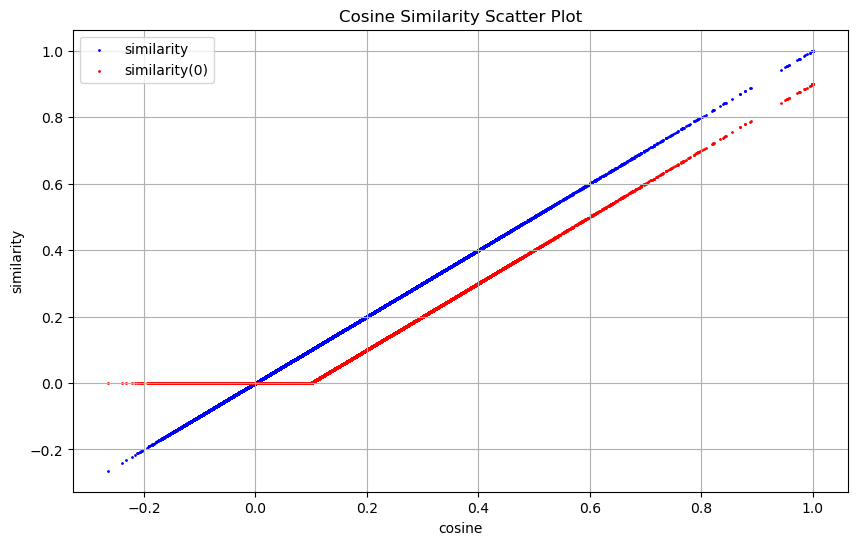

In [11]:
model = Top2Vec.load("top2vec_model")

document_embeddings = model.document_vectors

# Calculate the cosine similarity matrix
similarity_matrix = cosine_similarity(document_embeddings)

x_indices, y_indices = np.triu_indices(similarity_matrix.shape[0], k=1)

cosine_similarities = similarity_matrix[x_indices, y_indices]

similarity_offset = np.maximum(cosine_similarities - 0.1, 0) 


plt.figure(figsize=(10, 6))
plt.scatter(cosine_similarities, cosine_similarities, color='blue', s=1, label='similarity')  
plt.scatter(cosine_similarities, similarity_offset, color='red', s=1, label='similarity(0)')  
plt.xlabel('cosine')
plt.ylabel('similarity')
plt.legend()
plt.grid(True)
plt.title('Cosine Similarity Scatter Plot')
plt.show()


## Similarity Matrix with Custom Distance Metric

In [10]:
from scipy.spatial.distance import pdist, squareform

model = Top2Vec.load("top2vec_model")

document_embeddings = model.document_vectors

# Calculate the pairwise distance and convert to similarity
distance_matrix = pdist(document_embeddings, metric='euclidean')
similarity_matrix = 1 / (1 + squareform(distance_matrix))

print("Similarity Matrix with Custom Metric:\n", similarity_matrix)

Similarity Matrix with Custom Metric:
 [[1.         0.43586283 0.42650572 ... 0.41687874 0.4398661  0.434095  ]
 [0.43586283 1.         0.42004824 ... 0.43007671 0.43828062 0.43934503]
 [0.42650572 0.42004824 1.         ... 0.42280376 0.46063915 0.44348495]
 ...
 [0.41687874 0.43007671 0.42280376 ... 1.         0.4462792  0.42995006]
 [0.4398661  0.43828062 0.46063915 ... 0.4462792  1.         0.43919195]
 [0.434095   0.43934503 0.44348495 ... 0.42995006 0.43919195 1.        ]]


## Visualizing Extracted Topics from Top2Vec Model

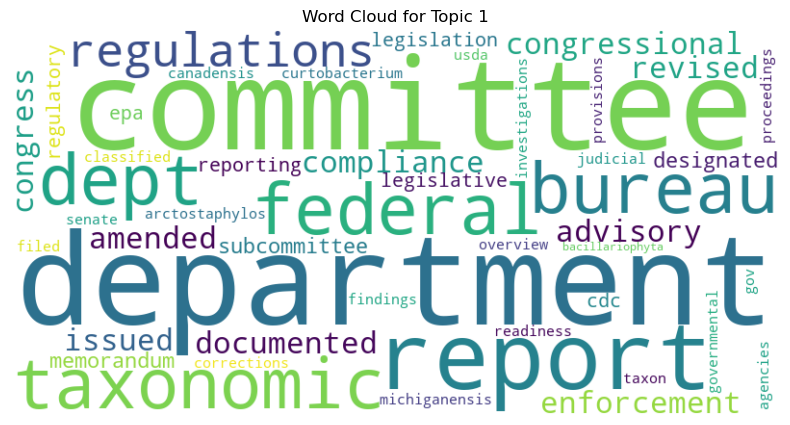

In [12]:
from wordcloud import WordCloud

model = Top2Vec.load("top2vec_model")

# Extract topics and their words
topics = model.get_topics()
topic_words = [topic[0] for topic in topics]

# Generate a word cloud for the first topic
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(topic_words[0]))


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Topic 1')
plt.show()